# **EDA**

In [87]:
import warnings
# import libraries
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style("darkgrid")

In [88]:
# find the filepath
file_path = Path.cwd().parent.joinpath("data", "raw", "clean_customer_churn.parquet")

# csv to dataframe
df = pd.read_parquet(file_path, engine="fastparquet")
df.head()

,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [89]:
# check description of churn customers
df[df["Churn Value"] == 1].describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,1869.000000,1869.000000,1869.000000,1869.0,1869.000000,1869.000000
mean,17.979133,74.441332,1531.796094,1.0,82.510433,4149.414660
std,19.531123,24.666053,1890.822994,0.0,10.328570,1189.370707
min,1.000000,18.850000,18.850000,1.0,65.000000,2003.000000
25%,2.000000,56.150000,134.500000,1.0,74.000000,3101.000000
50%,10.000000,79.650000,703.550000,1.0,82.000000,4238.000000
75%,29.000000,94.200000,2331.300000,1.0,91.000000,5166.000000
max,72.000000,118.350000,8684.800000,1.0,100.000000,6484.000000


In [90]:
df.columns

Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [104]:
df["customer_loyalty"] = pd.cut(
    x=df["Tenure Months"],
    bins=[-1, 1, 2, 10, 29, np.inf],
    labels=["new", "seeker", "floater", "loyal", "ultra_loyal"]
)
df[(df["customer_loyalty"] == "ultra_loyal") & (df["Churn Value"] == 1)][["Monthly Charges", "Total Charges"]].sort_values(by="Total Charges", ascending=False)

,Monthly Charges,Total Charges
1206,117.80,8684.80
339,115.55,8127.60
1026,109.25,8109.80
1729,115.65,7968.85
1468,113.15,7856.00
...,...,...
1095,28.60,973.55
1334,20.40,930.45
1573,24.50,740.30
504,19.55,658.95


## Target analysis

In [42]:
# overall idea
print(f"Number of rows: {len(df)}")
print(f"Total number of churn cases: {len(df[df["Churn Value"] == 1])}")
print(f"Percentage of churn:{df["Churn Value"].mean() * 100: .2f}%")

Number of rows: 7043
Total number of churn cases: 1869
Percentage of churn: 26.54%


In [43]:
# distribution of target column
df["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

## Numerical feature distribution

In [44]:
# select all the numerical columns
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols.remove("Churn Value")
num_cols

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']

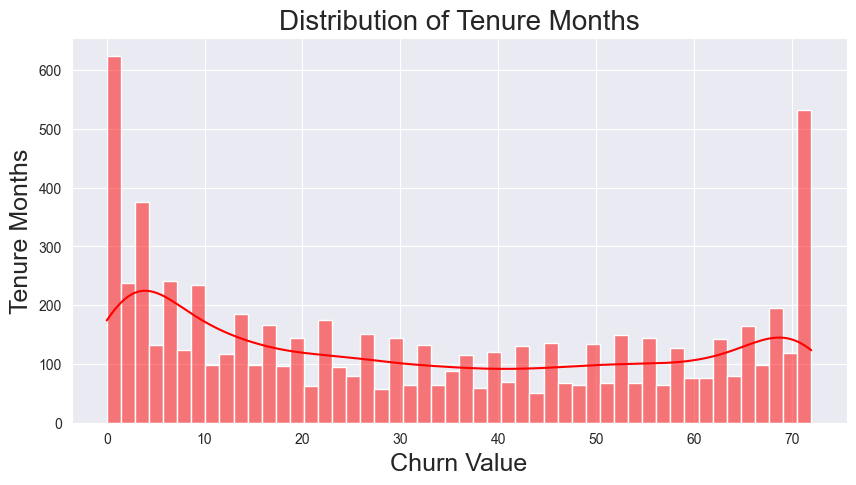

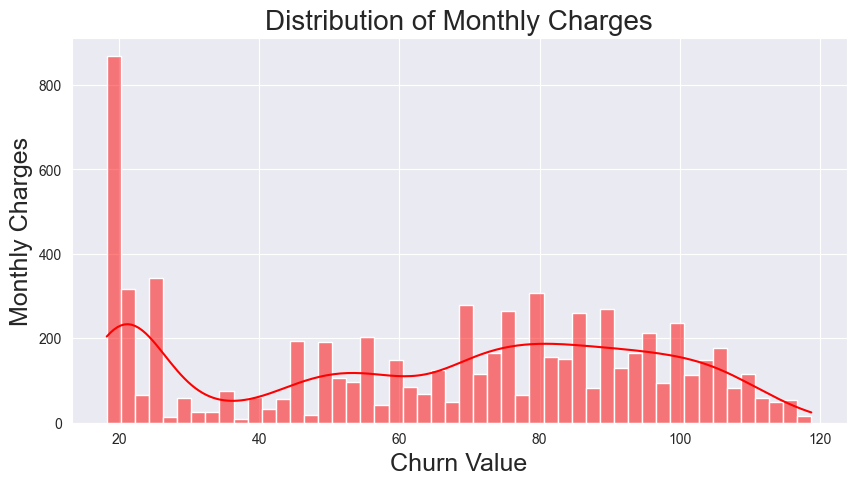

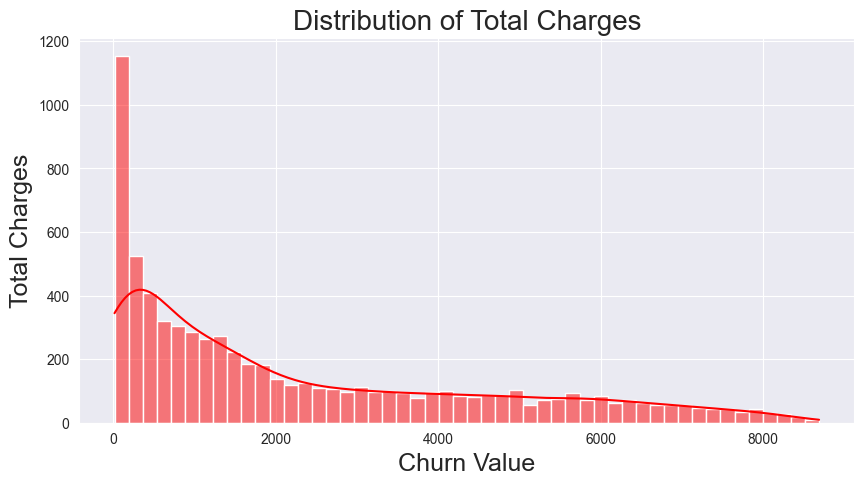

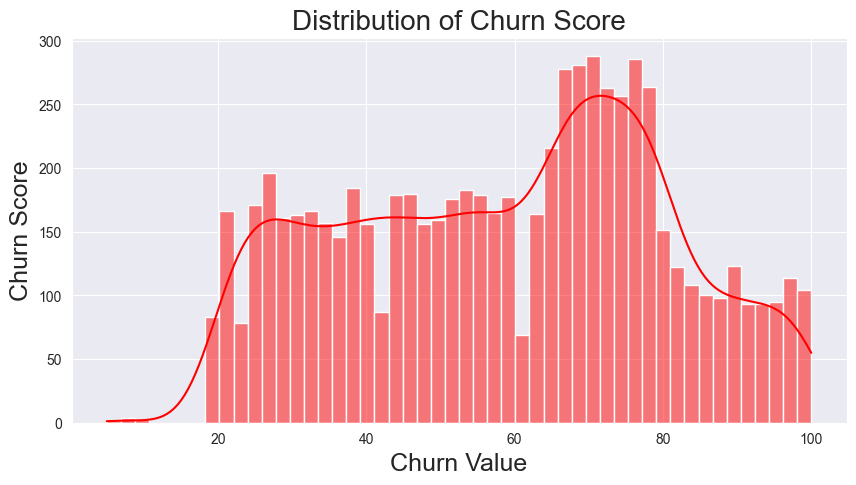

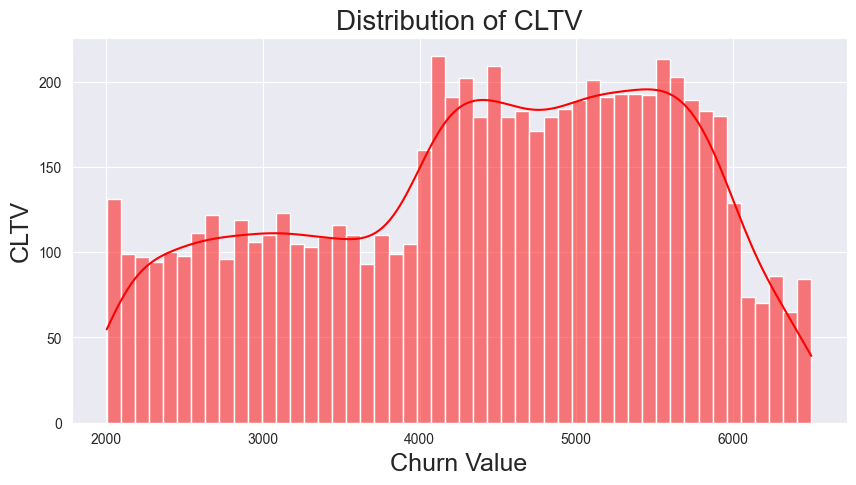

In [45]:
# looping through all the columns to plot histogram
for col in num_cols:
    plt.figure(figsize=[10, 5])
    sns.histplot(df[col], bins=50, kde=True, color='r', ax=plt.gca())
    plt.title(f"Distribution of {col}", fontsize=20)
    plt.xlabel("Churn Value", fontsize=18)
    plt.ylabel(col, fontsize=18)
    plt.show()

## Churn v/s Non-churn prediction

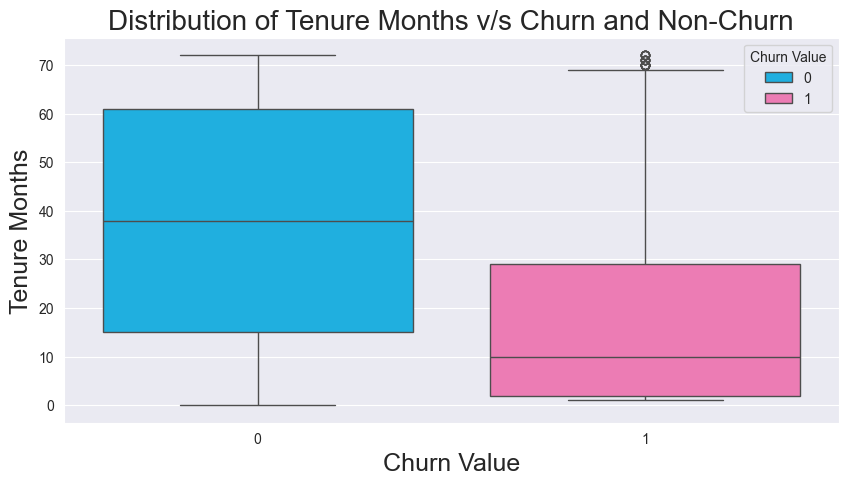

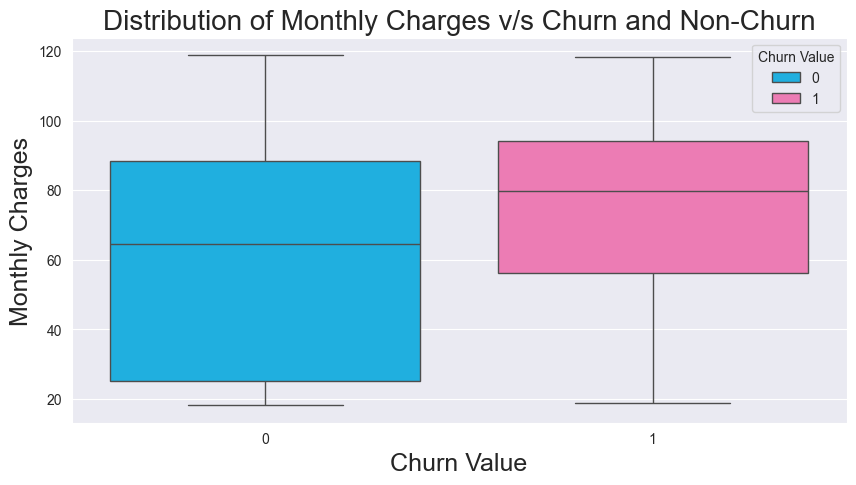

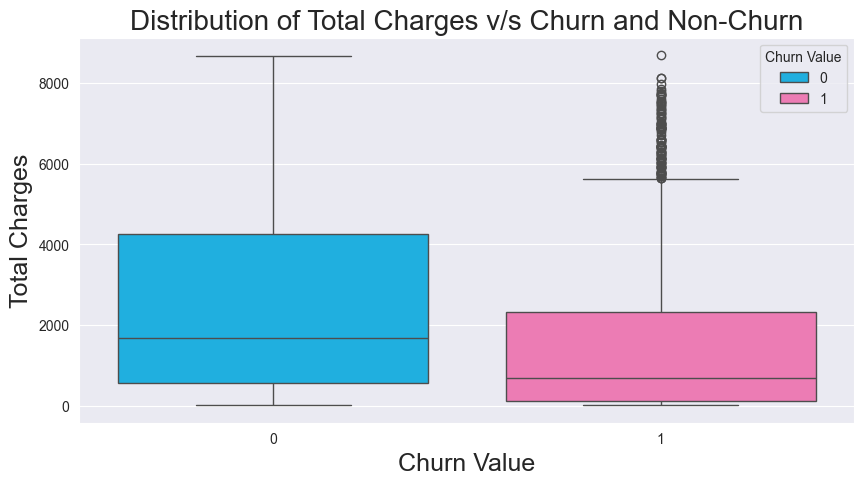

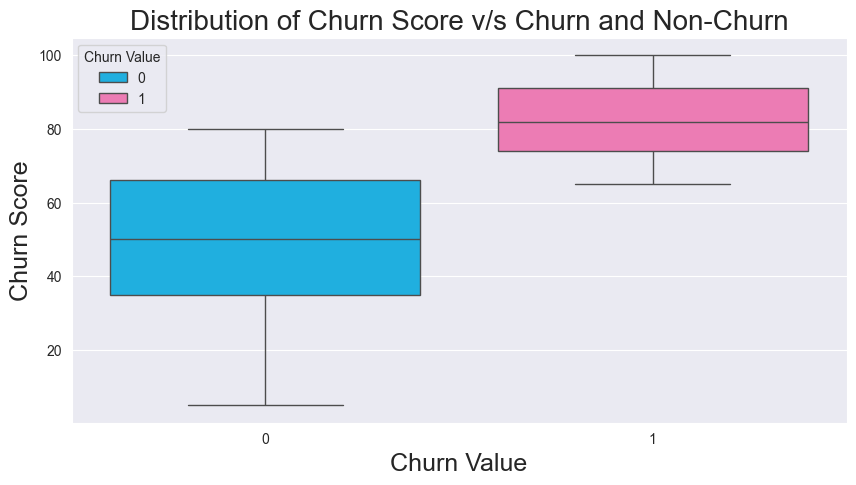

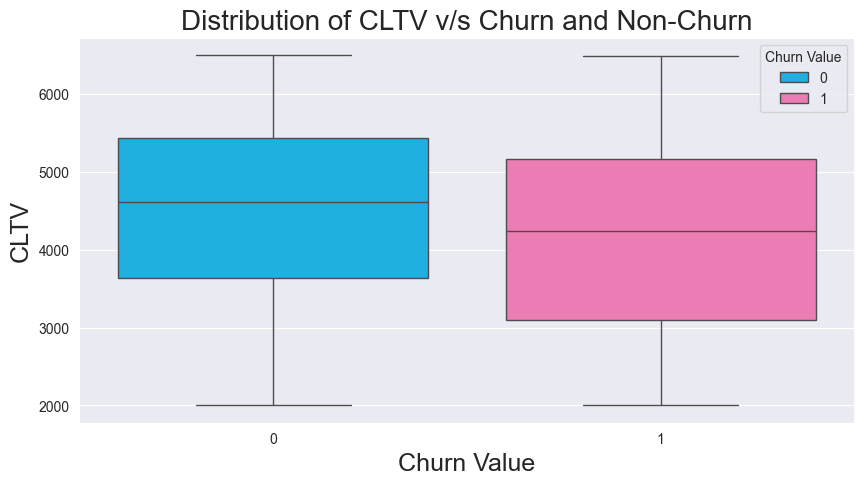

In [46]:
# looping through all the columns to predict churn
for col in num_cols:
    plt.figure(figsize=[10, 5])
    sns.boxplot(x='Churn Value', y=df[col], hue='Churn Value', palette=["deepskyblue", "hotpink"], data=df,
                ax=plt.gca())
    plt.title(f"Distribution of {col} v/s Churn and Non-Churn", fontsize=20)
    plt.xlabel("Churn Value", fontsize=18)
    plt.ylabel(col, fontsize=18)
    plt.show()

- The high paying customers are churning.
- `50%` of the customer churn before 10 months of service.
- The more tenure months customer serves, the less likely they will churn.

In [47]:
# select categorical columns
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
cat_cols.remove("Churn Label")
cat_cols.remove("City")
cat_cols.remove("Churn Reason")
cat_cols

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

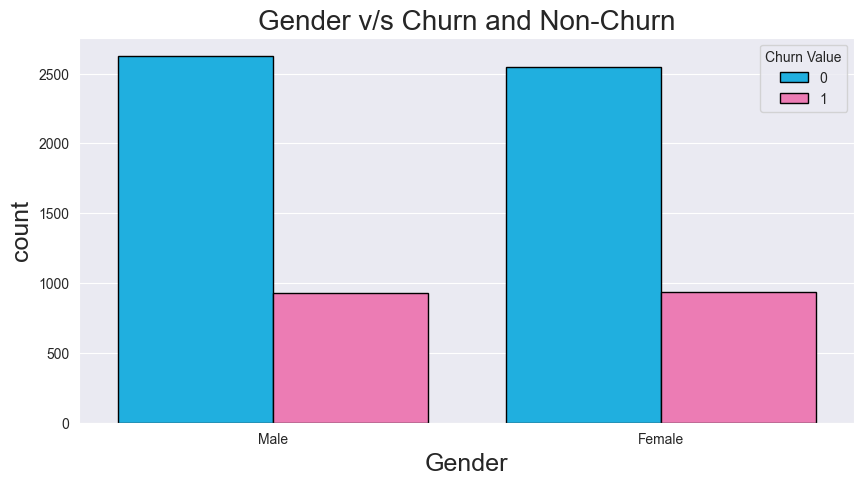

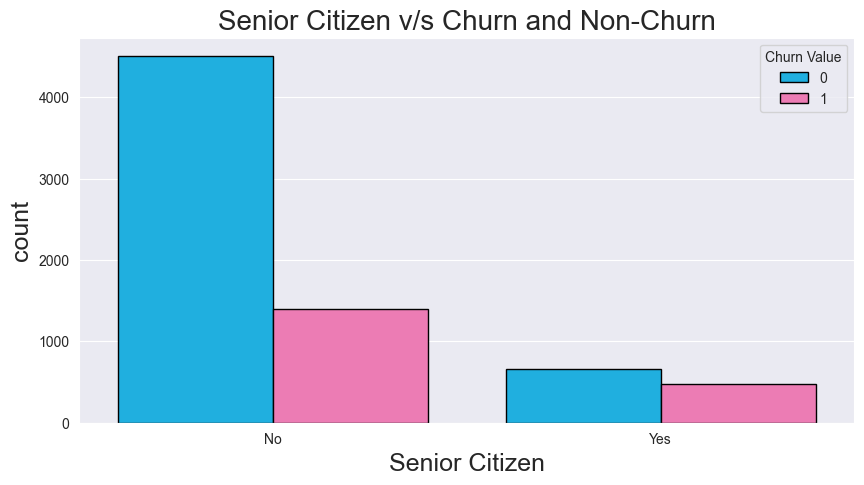

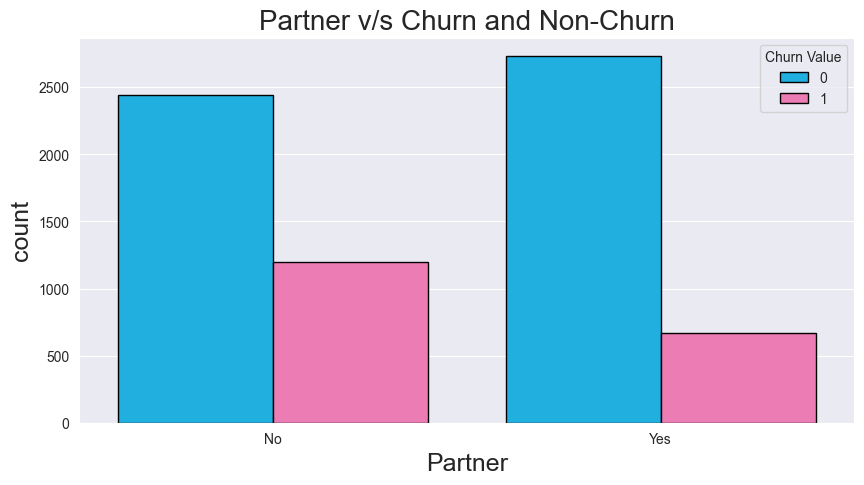

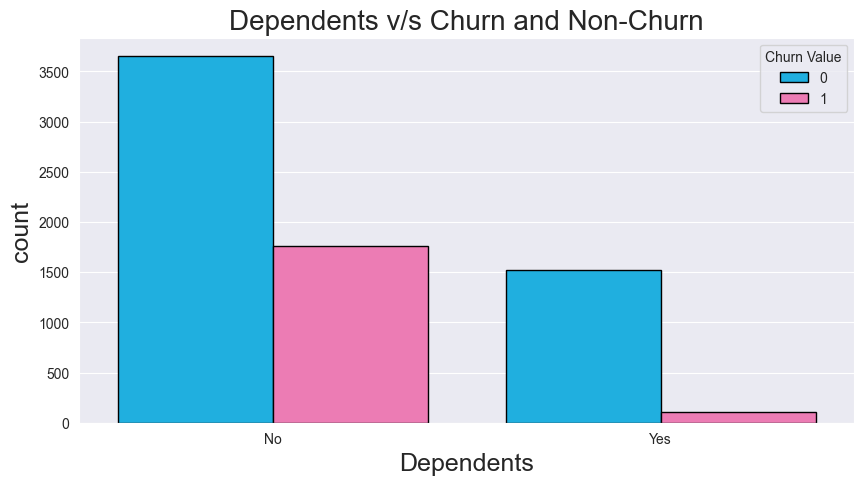

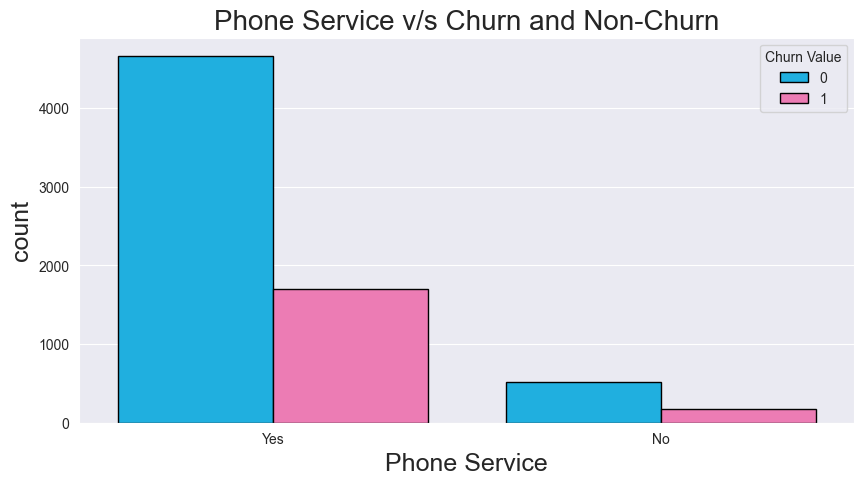

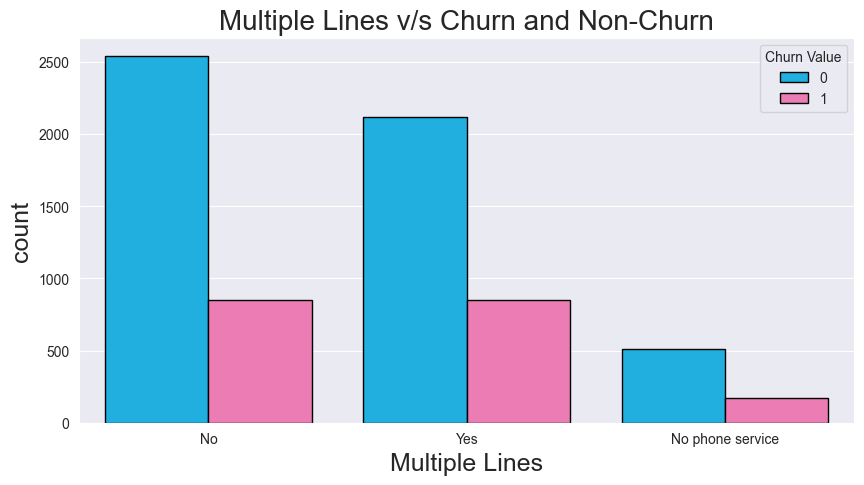

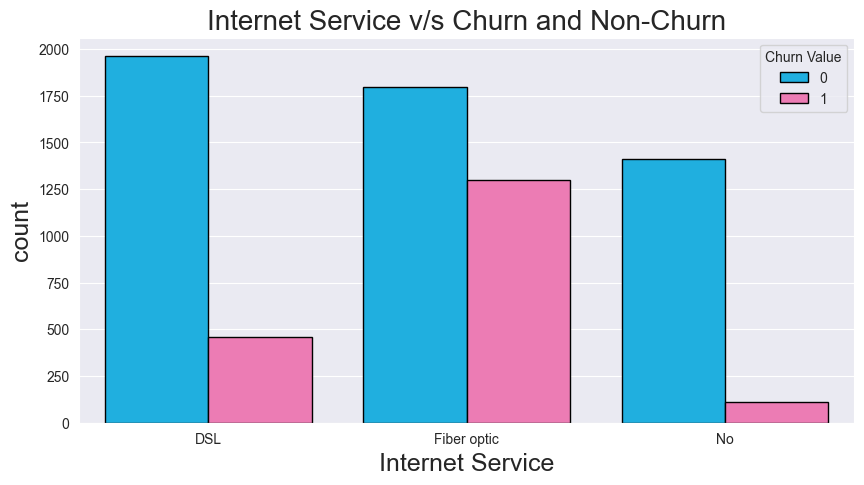

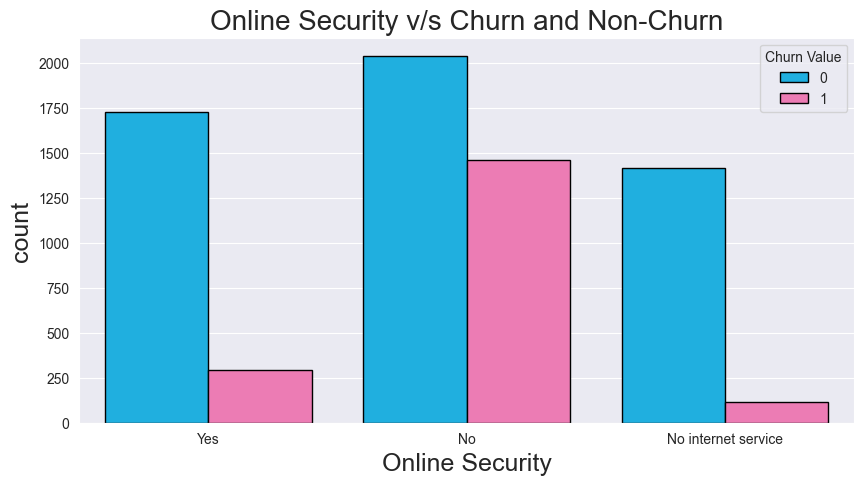

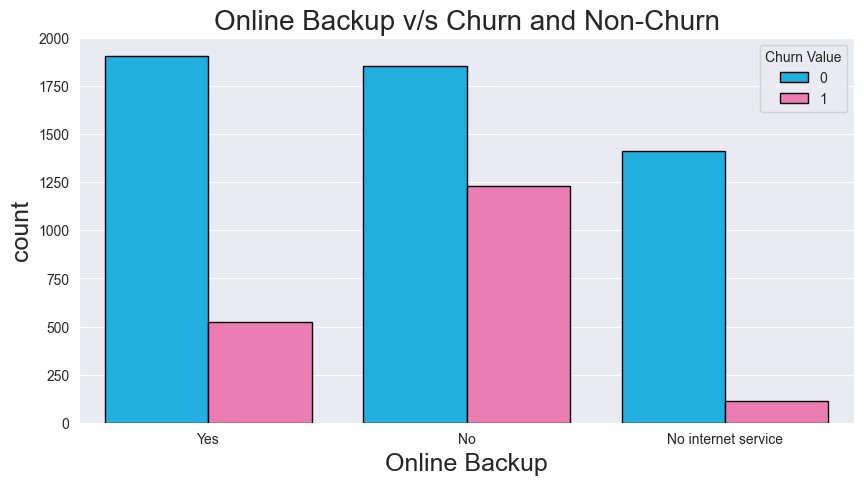

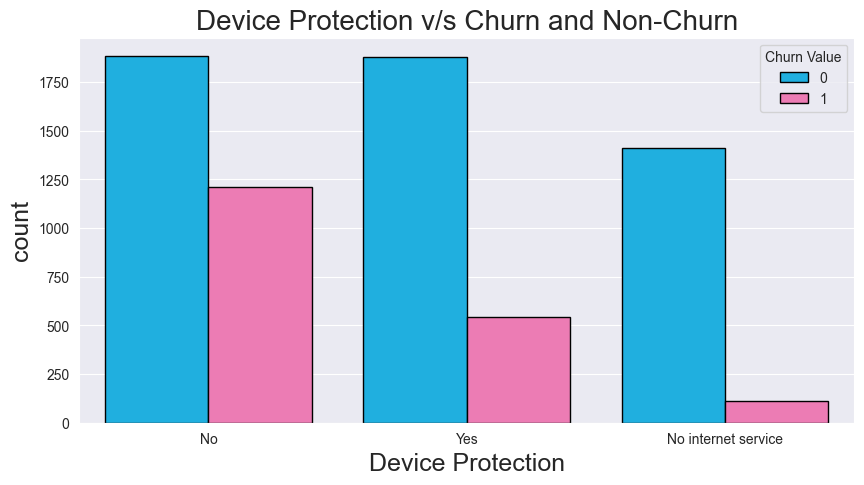

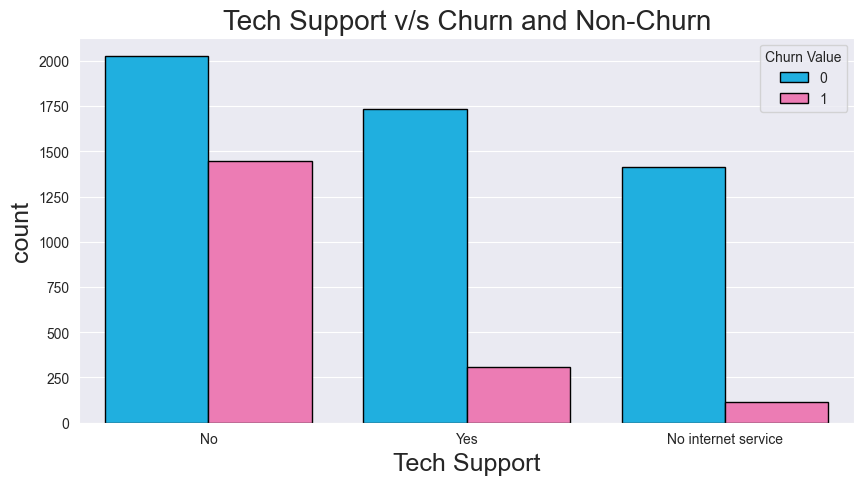

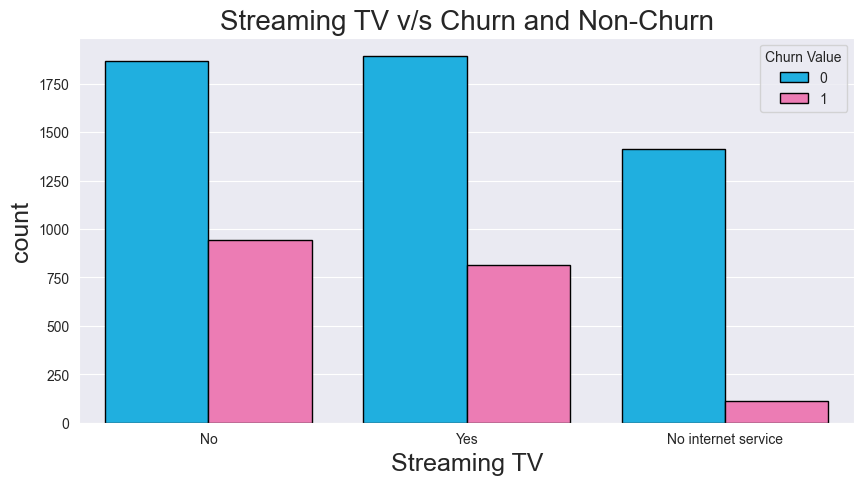

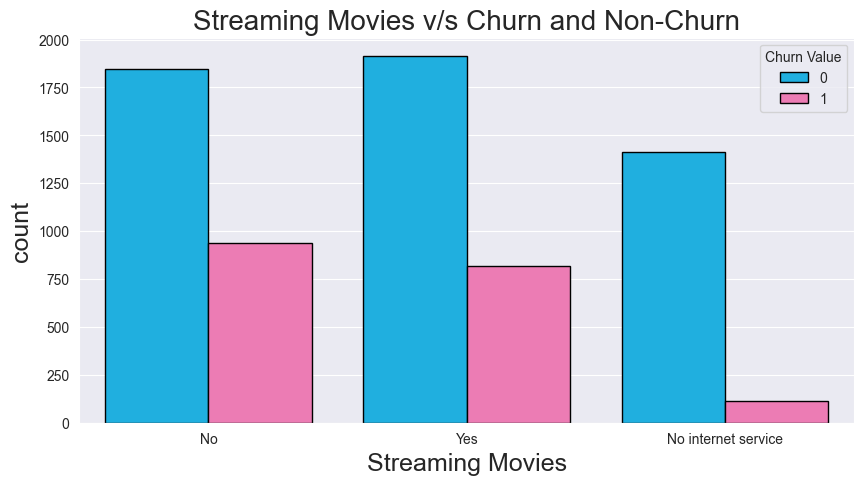

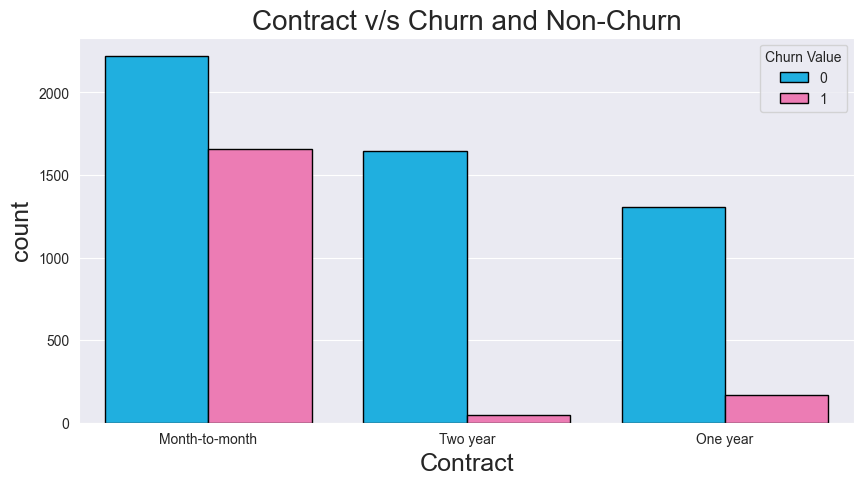

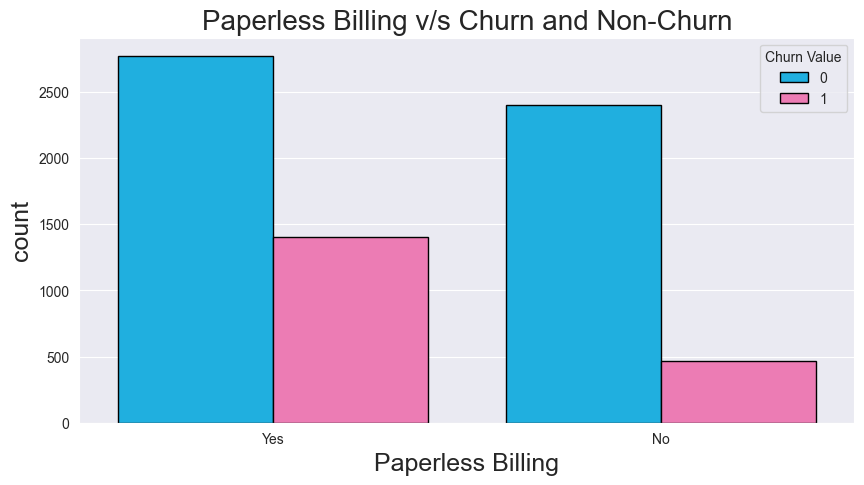

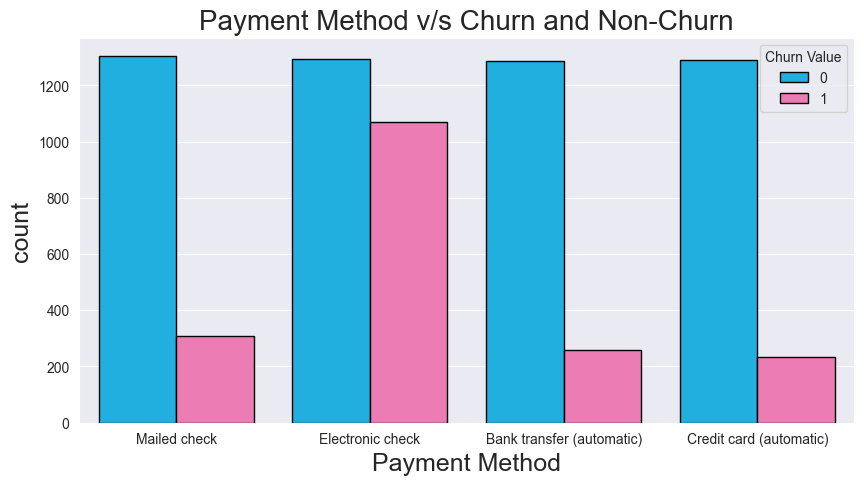

In [48]:
# loop through categorical columns and plot count plot
for col in cat_cols:
    plt.figure(figsize=[10, 5])
    sns.countplot(x=col, hue='Churn Value', data=df, ax=plt.gca(), palette=["deepskyblue", "hotpink"], edgecolor="k")
    plt.title(f"{col} v/s Churn and Non-Churn", fontsize=20)
    plt.xlabel(col, fontsize=18)
    plt.ylabel("count", fontsize=18)
    plt.show()

- Customers with no online security, Tech support, Device protection, Output backup have the high chances of churn.
- Customers with month-to-month contract have the high chances of churn.
- Customers who is a senior citizen have the high chances of churn.
- Customers who took a fiber optic connection have the high chances of churn.

## **Identifier Analysis**

In [49]:
# divide the dataset into two different dataset
df_pos = df[df["Churn Value"] == 1]
df_neg = df[df["Churn Value"] == 0]

In [50]:
# let's check if there is any null value in Churn reason feature
df_pos["Churn Reason"].isna().any()

np.False_

### Distribution of churn reason

In [51]:
# percentage of churn reason
df_pos["Churn Reason"].value_counts() * 100 / len(df_pos)

Churn Reason
Attitude of support person                   10.272873
Competitor offered higher download speeds    10.112360
Competitor offered more data                  8.667737
Don't know                                    8.239700
Competitor made better offer                  7.490637
Attitude of service provider                  7.223114
Competitor had better devices                 6.955591
Network reliability                           5.510968
Product dissatisfaction                       5.457464
Price too high                                5.243446
Service dissatisfaction                       4.761905
Lack of self-service on Website               4.708400
Extra data charges                            3.049759
Moved                                         2.835741
Limited range of services                     2.354200
Lack of affordable download/upload speed      2.354200
Long distance charges                         2.354200
Poor expertise of phone support               1.0700

### Q. Churn reason for the mid-valuable customer?

In [52]:
# Quantile range calculation
Q1 = df_pos['Monthly Charges'].quantile(0.25)
Q3 = df_pos['Monthly Charges'].quantile(0.75)

mid_valued_customer = df_pos[(df_pos['Monthly Charges'] >= Q1) & (df_pos['Monthly Charges'] <= Q3)]

mid_valued_customer["Churn Reason"].value_counts()

Churn Reason
Attitude of support person                   97
Competitor offered higher download speeds    94
Competitor offered more data                 79
Don't know                                   76
Competitor made better offer                 75
Attitude of service provider                 62
Competitor had better devices                58
Network reliability                          54
Price too high                               52
Lack of self-service on Website              51
Product dissatisfaction                      44
Service dissatisfaction                      40
Moved                                        31
Extra data charges                           28
Limited range of services                    24
Long distance charges                        24
Lack of affordable download/upload speed     20
Poor expertise of online support             13
Poor expertise of phone support              10
Deceased                                      4
Name: count, dtype: int64

### Q. Churn reasons for highest valuable customers?

In [53]:
high_value_customers = df_pos[df_pos["Monthly Charges"] >= Q3]
high_value_customers["Churn Reason"].value_counts()

Churn Reason
Competitor offered higher download speeds    48
Competitor offered more data                 48
Attitude of support person                   45
Attitude of service provider                 42
Competitor made better offer                 35
Competitor had better devices                34
Don't know                                   33
Price too high                               28
Product dissatisfaction                      28
Service dissatisfaction                      28
Network reliability                          19
Extra data charges                           17
Lack of self-service on Website              16
Moved                                        14
Lack of affordable download/upload speed     12
Long distance charges                        12
Limited range of services                     7
Poor expertise of phone support               5
Poor expertise of online support              1
Name: count, dtype: int64

### Q. In which city the competitors are offering higher download speeds?

In [54]:
df_pos[df_pos["Churn Reason"] == "Competitor offered higher download speeds"]['City'].value_counts()

City
Los Angeles      12
San Diego         7
Sacramento        6
San Francisco     5
San Jose          4
                 ..
Agoura Hills      1
Winnetka          1
El Centro         1
Seeley            1
Vidal             1
Name: count, Length: 141, dtype: int64

### Q. In which city the Competitors offered more data?

In [55]:
# count the number of cities
df_pos[df_pos["Churn Reason"] == "Competitor offered more data"]["City"].value_counts()

City
Los Angeles      11
Sacramento        8
San Jose          4
San Francisco     4
Palmdale          3
                 ..
Pacoima           1
Reseda            1
San Fernando      1
Heber             1
White Water       1
Name: count, Length: 128, dtype: int64

### Q. In which city the Attitude of support person is a reason for churn?

In [56]:
df_pos[df_pos["Churn Reason"] == "Attitude of support person"]["City"].value_counts()

City
Los Angeles        5
Glendale           4
San Diego          4
Long Beach         3
North Hollywood    3
                  ..
Del Mar            1
Escondido          1
Solana Beach       1
San Marcos         1
Indio              1
Name: count, Length: 161, dtype: int64

### Q. What is the churn reason of customers according to top 5 cities?

In [57]:
df_pos["City"].value_counts()

City
Los Angeles      90
San Diego        50
San Francisco    31
San Jose         29
Sacramento       26
                 ..
Poway             1
Beaumont          1
Cabazon           1
Calipatria        1
El Centro         1
Name: count, Length: 833, dtype: int64

In [58]:
df_pos[df_pos["City"] == "Los Angeles"]["Churn Reason"].value_counts()

Churn Reason
Competitor offered higher download speeds    12
Competitor offered more data                 11
Competitor made better offer                  9
Competitor had better devices                 9
Extra data charges                            9
Moved                                         6
Don't know                                    6
Attitude of support person                    5
Product dissatisfaction                       4
Service dissatisfaction                       4
Lack of self-service on Website               4
Network reliability                           4
Price too high                                3
Limited range of services                     2
Lack of affordable download/upload speed      1
Long distance charges                         1
Name: count, dtype: int64

In [59]:
df_pos[df_pos["City"] == "San Diego"]["Churn Reason"].value_counts()

Churn Reason
Product dissatisfaction                      10
Competitor offered higher download speeds     7
Don't know                                    6
Attitude of service provider                  6
Attitude of support person                    4
Service dissatisfaction                       3
Poor expertise of online support              2
Poor expertise of phone support               2
Price too high                                2
Network reliability                           2
Competitor had better devices                 1
Lack of self-service on Website               1
Limited range of services                     1
Lack of affordable download/upload speed      1
Long distance charges                         1
Extra data charges                            1
Name: count, dtype: int64

In [60]:
df_pos[df_pos["City"] == "San Francisco"]["Churn Reason"].value_counts()

Churn Reason
Competitor offered higher download speeds    5
Price too high                               4
Competitor offered more data                 4
Don't know                                   3
Competitor made better offer                 3
Competitor had better devices                3
Product dissatisfaction                      2
Service dissatisfaction                      2
Moved                                        2
Extra data charges                           1
Lack of self-service on Website              1
Network reliability                          1
Name: count, dtype: int64

In [61]:
df_pos[df_pos["City"] == "San Jose"]["Churn Reason"].value_counts()

Churn Reason
Competitor offered higher download speeds    4
Competitor offered more data                 4
Competitor had better devices                3
Moved                                        3
Service dissatisfaction                      2
Lack of self-service on Website              2
Network reliability                          2
Deceased                                     1
Competitor made better offer                 1
Limited range of services                    1
Lack of affordable download/upload speed     1
Long distance charges                        1
Extra data charges                           1
Price too high                               1
Product dissatisfaction                      1
Don't know                                   1
Name: count, dtype: int64

In [62]:
df_pos[df_pos["City"] == "Sacramento"]["Churn Reason"].value_counts()

Churn Reason
Competitor offered more data                 8
Competitor offered higher download speeds    6
Competitor had better devices                3
Competitor made better offer                 2
Lack of self-service on Website              1
Network reliability                          1
Limited range of services                    1
Lack of affordable download/upload speed     1
Long distance charges                        1
Extra data charges                           1
Price too high                               1
Name: count, dtype: int64

In [76]:
df.columns

Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

### Correlation Analysis

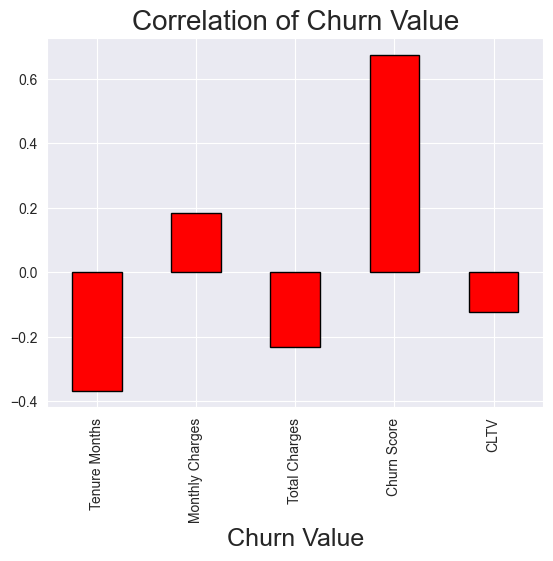

In [25]:
# correlation analysis
corr_matrix = df.corr(numeric_only=True, method="spearman")["Churn Value"]
corr_matrix.drop("Churn Value").plot(kind="bar", edgecolor="k", color="red")
plt.title("Correlation of Churn Value", fontsize=20)
plt.xlabel("Churn Value", fontsize=18)
plt.show()

## **Final Verdict**

- The high value customers and the mid-valued customers which pay more than `$51` dollar churn because of competitor offering higher download speeds and more data. They look for the best service possible. Los Angeles, San Francisco, San Diego, San Jose, Sacramento are the top 5 cities affected by this type of churn.
- Customer support should talk with more politely.

###